In [2]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
import matplotlib as mpl

from frequency_processing import load_lines

In [3]:
plt.rcParams.update({'axes.linewidth' : 1.5,
                     'ytick.major.width' : 1.5,
                     'ytick.minor.width' : 1.5,
                     'xtick.major.width' : 1.5,
                     'xtick.minor.width' : 1.5,
                     'xtick.labelsize': 12, 
                     'ytick.labelsize': 12,
                     'axes.labelsize': 18,
                     'axes.labelpad' : 5,
                     'axes.titlesize' : 20,
                     'axes.titlepad' : 10,
                     'font.family': 'Serif'
                    })

mpl.rcParams['mathtext.fontset'] = 'cm'          # Computer Modern serif
mpl.rcParams['mathtext.rm'] = 'serif'

0.0 data points discarded
0.0 data points discarded
bootstrapping false alarm line
bootstrapping false alarm line


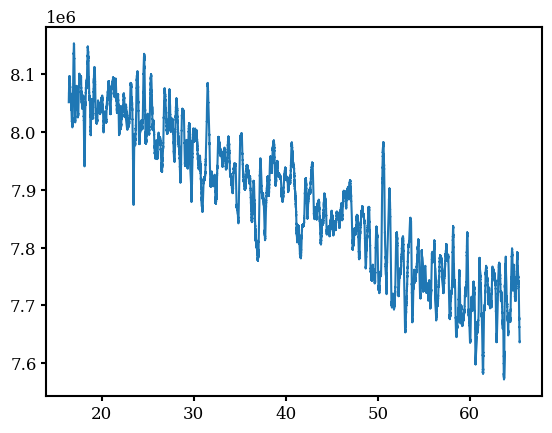

In [10]:
# K2 processing; shout out prof. Jason Rowe for the data

with open('/scratch11/ktp9/DIA/phot.m2.20160224.cjp.dat', 'r') as file:
    lines = file.readlines()

# Process the lines as needed
k2 = []
for line in lines:
    # Assume space-separated values, adjust as needed
    values = line.strip().split()
    k2.append([float(v) for v in values])

k2_array = np.array(k2)
timesk2 = k2_array[:,0] #(BTJD offset)
fluxk2 = k2_array[:,1]

plt.plot(timesk2, fluxk2)

k2_grouped_flux = group_and_average(fluxk2, n42_flux)
k2_grouped_time = group_and_average(timesk2, n42_time)

k2_frequency_dt, k2_power_dt, k2_false_alarm_dt, k2_flux_detrended, k2_peak_frequencies_dt = get_periodogram(k2_grouped_time, k2_grouped_flux, 1, probability=0.001)


[0.03721122 0.12564768 0.17326731 0.26850657 0.37054864 0.41136547
 0.4657879  0.50660473 0.54061875 0.77871691 0.85354776 1.27532164
 1.30933566 1.34334969 1.42498334 1.45899736 2.62227694 2.84676949]


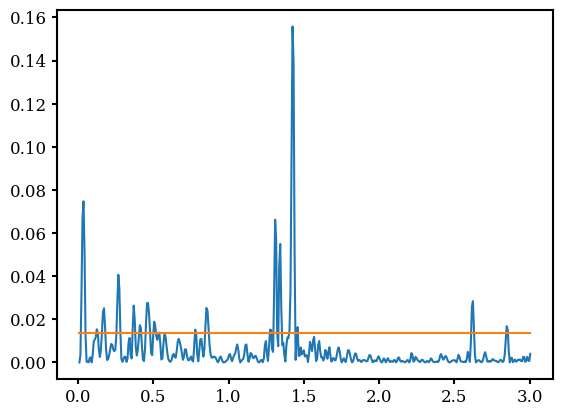

In [18]:
plt.plot(k2_frequency_dt, k2_power_dt)
plt.plot(k2_frequency_dt, np.full_like(k2_frequency_dt, k2_false_alarm_dt))
print(k2_peak_frequencies_dt)

In [4]:
directory = "/scratch11/ktp9/TESS_SolarSystem/"
specs = "results_bps40_pps10/"

n42 = directory + "Neptune/s42_cam2_ccd4/" + specs
n70 = directory + "Neptune/s70_cam1_ccd1/" + specs

u42 = directory + "Uranus/s42_cam4_ccd2/" + specs
u43 = directory + "Uranus/s43_cam2_ccd1/" + specs
u44 = directory + "Uranus/s44_cam1_ccd4/" + specs

In [5]:
def extract_data(name, sector, cam, ccd, directory=directory, specs=specs):
    time, flux = load_lines(directory + "%s/s%i_cam%i_ccd%i/" %(name, sector, cam, ccd) + specs + "lc_%s_s%i_cam%i_ccd%i.txt" %(name, sector, cam, ccd))
    frequency, power = load_lines(directory + "%s/s%i_cam%i_ccd%i/" %(name, sector, cam, ccd) + specs + "periodogram_%s_s%i_cam%i_ccd%i.txt" %(name, sector, cam, ccd))
    false_alarm = np.load(directory + "%s/s%i_cam%i_ccd%i/" %(name, sector, cam, ccd) + specs + "false_alarm_0_%s_s%i_cam%i_ccd%i.npy" %(name, sector, cam, ccd))
    return time, flux, frequency, power, false_alarm

In [6]:
n42_time, n42_flux, n42_frequency, n42_power, n42_fa = extract_data("Neptune", 42, 2, 4)
n70_time, n70_flux, n70_frequency, n70_power, n70_fa = extract_data("Neptune", 70, 1, 1)

u42_time, u42_flux, u42_frequency, u42_power, u42_fa = extract_data("Uranus", 42, 4, 2)
u43_time, u43_flux, u43_frequency, u43_power, u43_fa = extract_data("Uranus", 43, 2, 1)
u44_time, u44_flux, u44_frequency, u44_power, u44_fa = extract_data("Uranus", 44, 1, 4)

In [7]:
import numpy as np

def group_and_average(arr1, arr2):
    """
    Groups elements of arr1 so that the number of groups matches the size of arr2.
    Returns an array of the averages of each group.
    """
    arr1 = np.asarray(arr1)
    arr2 = np.asarray(arr2)
    
    len1 = len(arr1)
    len2 = len(arr2)

    if len2 == 0:
        raise ValueError("arr2 must have non-zero length.")
    if len1 < len2:
        raise ValueError("arr1 must be at least as long as arr2.")
    
    # Compute group size (may not be perfect division)
    group_size = len1 / len2

    result = []
    for i in range(len2):
        start = int(round(i * group_size))
        end = int(round((i + 1) * group_size))
        group = arr1[start:end]
        avg = np.mean(group) if len(group) > 0 else 0
        result.append(avg)

    print(f"{len(arr1) - len(result)*group_size} data points discarded")
    return np.array(result)


In [52]:
n70_grouped_flux = group_and_average(n70_flux, n42_flux)
n70_grouped_time = group_and_average(n70_time, n42_time)

0.0 data points discarded
0.0 data points discarded


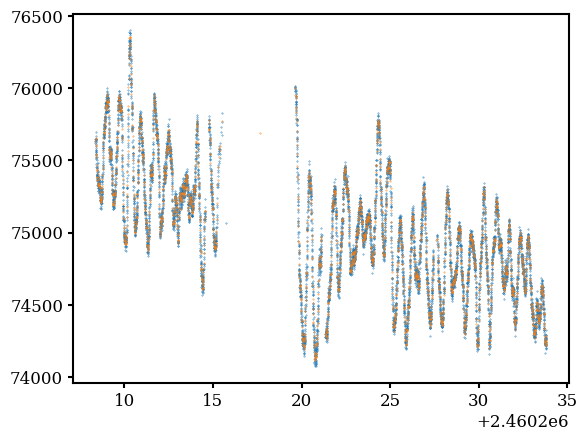

2575


In [53]:
plt.scatter(n70_time, n70_flux, s=0.1)
plt.scatter(n70_grouped_time, n70_grouped_flux, s=0.1)
plt.show()

print(len(n70_grouped_time))

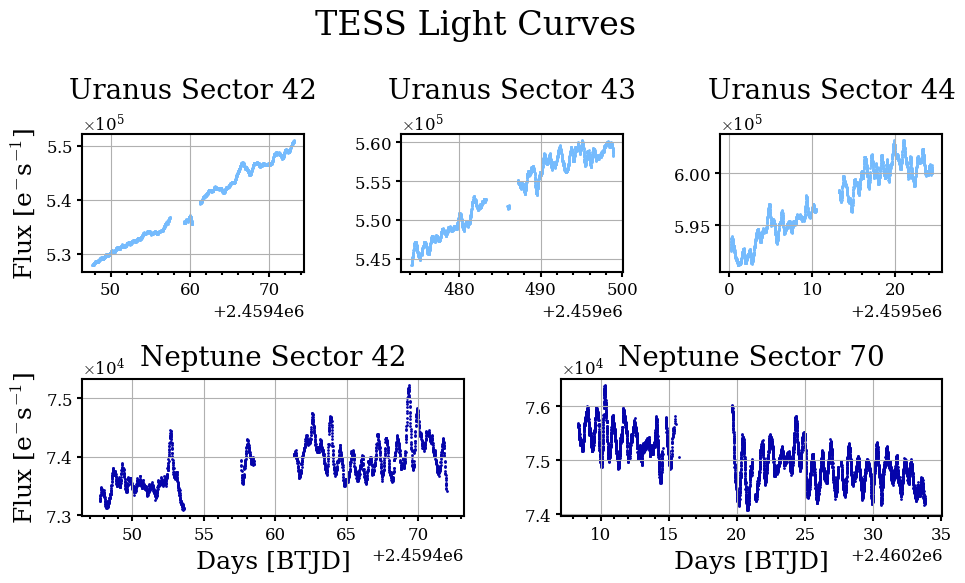

In [7]:
###### import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def scatter_data(axs, name, sector, x, y, color):
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((0, 0))  # Forces scientific notation for small/large numbers

    axs.set_title(name + " Sector " + str(sector))
    axs.scatter(x, y, s=1, color=color)
    axs.grid(True)
    axs.yaxis.set_major_formatter(formatter)
    axs.xaxis.set_minor_locator(AutoMinorLocator())
    axs.figure.canvas.draw()

# Create the figure
fig = plt.figure(figsize=(10, 6))

fig.suptitle("TESS Light Curves", fontsize=24)

# Define a 2-row, 3-column grid
gs = gridspec.GridSpec(2, 6, height_ratios=[1, 1])

# Top row: 3 equal-width panels
ax1 = fig.add_subplot(gs[0, 0:2])
u42_flux[1400:1600] = np.nan
scatter_data(ax1, "Uranus", 42, u42_time, u42_flux, color="xkcd:sky blue")
ax1.set_ylabel("Flux [e$^{-}$s$^{-1}$]")

ax2 = fig.add_subplot(gs[0, 2:4])
scatter_data(ax2, "Uranus", 43, u43_time, u43_flux, color="xkcd:sky blue")

ax3 = fig.add_subplot(gs[0, 4:6])
scatter_data(ax3, "Uranus", 44, u44_time, u44_flux, color="xkcd:sky blue")

# Bottom row: panel 4 on columns 0–1, panel 5 on column 2
ax4 = fig.add_subplot(gs[1, 0:3])
n42_flux[975:1040] = np.nan
scatter_data(ax4, "Neptune", 42, n42_time, n42_flux, color="xkcd:royal blue")
ax4.set_ylabel("Flux [e$^{-}$s$^{-1}$]")
ax4.set_xlabel("Days [BTJD]")

ax5 = fig.add_subplot(gs[1, 3:6])
scatter_data(ax5, "Neptune", 70, n70_time, n70_flux, color="xkcd:royal blue")
ax5.set_xlabel("Days [BTJD]")

plt.tight_layout()
plt.savefig(directory + "poster_lc", dpi=1000)


In [9]:
from astropy.timeseries import LombScargle
from scipy.signal import find_peaks

def make_periodogram(ls, minimum_frequency=0.01, maximum_frequency=3, samples_per_peak=3, probability=0.05, bootstrap=False):
    frequency, power = ls.autopower(minimum_frequency=minimum_frequency, maximum_frequency=maximum_frequency, samples_per_peak=samples_per_peak) #0.0001, 3
    if bootstrap:
        print("bootstrapping false alarm line")
        n_bootstrap = 1000 # also try 100000 if it's fast
        false_alarm = ls.false_alarm_level(probability, method='bootstrap', method_kwds=dict(n_bootstraps=n_bootstrap))
    else: 
        false_alarm = ls.false_alarm_level(probability, method="baluev")
    return frequency, power, false_alarm
    
def detrend_max_freq(times, flux, probability=0.05, \
                        minimum_frequency=0.01, maximum_frequency=3, samples_per_peak=3, bootstrap=False):

    ls = LombScargle(times, flux)

    frequency, power, false_alarm = make_periodogram(ls, minimum_frequency, maximum_frequency, samples_per_peak, probability, bootstrap=bootstrap)

    false_alarm_array = np.full_like(power, false_alarm)

    # print("False alarm threshold:", false_alarm)
    # print("Max power:", np.max(power))

    peaks, _ = find_peaks(power, height=false_alarm_array)
    peak_frequencies = frequency[peaks]

    long_frequency = frequency[np.argmax(power)]

    flux_median = np.median(flux)
    subtraction = ls.model(times, long_frequency)
    flux_detrended = flux - subtraction + flux_median

    ls_detrended = LombScargle(times, flux_detrended)
    frequency_dt, power_dt, false_alarm_dt = make_periodogram(ls_detrended, minimum_frequency, maximum_frequency, samples_per_peak, probability, bootstrap=bootstrap)

    best_frequency_dt = frequency_dt[np.argmax(power_dt)]

    best_period_dt = 1 / best_frequency_dt

    false_alarm_array_dt = np.full_like(power_dt, false_alarm_dt)

    peaks_dt, _ = find_peaks(power_dt, height=false_alarm_array_dt)
    peak_frequencies_dt = frequency_dt[peaks_dt]

    # print(f"peak frequencies: {peak_frequencies_dt}")

    # plt.scatter(times, flux, color='green', label='input data', s=1)
    # plt.plot(times, subtraction, color="xkcd:royal blue", label=f'Best fit curve')
    # plt.scatter(times, flux_detrended, s=1, label="Detrended", color='red')
    # plt.show(

    return frequency_dt, power_dt, false_alarm_dt, flux_detrended, peak_frequencies_dt

def get_periodogram(times_obs, flux_detrended, detrend_count, probability=0.001):
    
    for count in range(detrend_count):
        frequency_dt, power_dt, false_alarm_dt, flux_detrended, peak_frequencies_dt = detrend_max_freq(times_obs, flux_detrended, probability=probability, bootstrap=True)
        
    return frequency_dt, power_dt, false_alarm_dt, flux_detrended, peak_frequencies_dt

In [55]:
# mask_indices_u42 = np.r_[0:1400, 1600:len(u42_flux)] 
# mask_indices_n42 = np.r_[0:975, 1040:len(n42_flux)]
# downsample_n70_to_n42 = len(n70_flux) // len(n42_flux)

# print("uranus")
# u42_frequency_dt, u42_power_dt, u42_false_alarm_dt, u42_flux_detrended, u42_peak_frequencies_dt = get_periodogram(u42_time[mask_indices_u42], u42_flux[mask_indices_u42], 1, probability=0.1)
# u43_frequency_dt, u43_power_dt, u43_false_alarm_dt, u43_flux_detrended, u43_peak_frequencies_dt = get_periodogram(u43_time, u43_flux, 1, probability=0.01)
# u44_frequency_dt, u44_power_dt, u44_false_alarm_dt, u44_flux_detrended, u44_peak_frequencies_dt = get_periodogram(u44_time, u44_flux, 1, probability=0.01)

print("neptune")
#n42_frequency_dt, n42_power_dt, n42_false_alarm_dt, n42_flux_detrended, n42_peak_frequencies_dt = get_periodogram(n42_time[mask_indices_n42], n42_flux[mask_indices_n42], 1, probability=0.001)
n70_frequency_dt, n70_power_dt, n70_false_alarm_dt, n70_flux_detrended, n70_peak_frequencies_dt = get_periodogram(n70_grouped_time, n70_grouped_flux, 1, probability=0.001)

# plt.plot(n70_frequency_dt, _power_dt)
# plt.axhline(n70_false_alarm_dt)
# plt.show()

neptune
bootstrapping false alarm line
bootstrapping false alarm line


In [56]:
# np.savez(directory + "u42_stack.npz",
#          frequency=u42_frequency_dt,
#          power=u42_power_dt,
#          false_alarm=u42_false_alarm_dt,
#          flux=u42_flux_detrended,
#          peak_freqs=u42_peak_frequencies_dt)

# np.savez(directory + "u43_stack.npz",
#          frequency=u43_frequency_dt,
#          power=u43_power_dt,
#          false_alarm=u43_false_alarm_dt,
#          flux=u43_flux_detrended,
#          peak_freqs=u43_peak_frequencies_dt)

# np.savez(directory + "u44_stack.npz",
#          frequency=u44_frequency_dt,
#          power=u44_power_dt,
#          false_alarm=u44_false_alarm_dt,
#          flux=u44_flux_detrended,
#          peak_freqs=u44_peak_frequencies_dt)

# np.savez(directory + "n42_stack.npz",
#          frequency=n42_frequency_dt,
#          power=n42_power_dt,
#          false_alarm=n42_false_alarm_dt,
#          flux=n42_flux_detrended,
#          peak_freqs=n42_peak_frequencies_dt)

np.savez(directory + "n70_stack.npz",
         frequency=n70_frequency_dt,
         power=n70_power_dt,
         false_alarm=n70_false_alarm_dt,
         flux=n70_flux_detrended,
         peak_freqs=n70_peak_frequencies_dt)

In [9]:
n42_peaks = [0.10602503, 0.14717862, 0.24320365, 0.28435724, 0.33922869, 0.39410013,
             0.54499661, 0.59986806, 0.72332882, 1.25832543, 1.31319688, 1.43665764,
             1.50524695, 1.56011839, 1.77960418, 1.84819349]
n42_fap_01 = 0.019044213804778096

n70_peaks = [0.10440271, 0.2392372, 0.30669422, 0.40109693, 0.49549964, 0.56293014, 
             0.67081895, 0.72476336, 0.83265216, 0.90008267, 0.95402707, 1.10237418,
             1.345124, 1.41255451, 1.46649891, 1.52044332]
n70_fap_01 = 0.011941806586368854

plt.plot(n42_frequency_dt, n42_power_dt)
plt.show()

# plt.plot(n70_frequency_dt, n70_power_dt)
# plt.show()


NameError: name 'n42_frequency_dt' is not defined

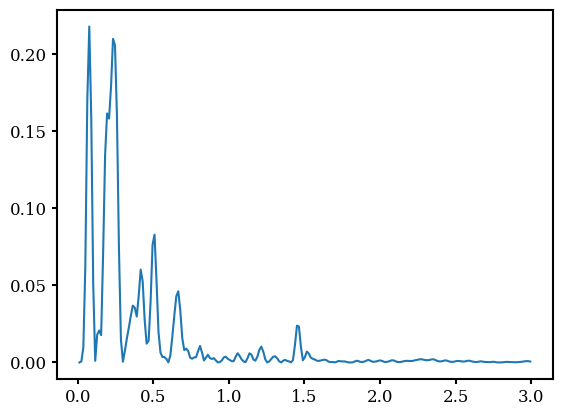

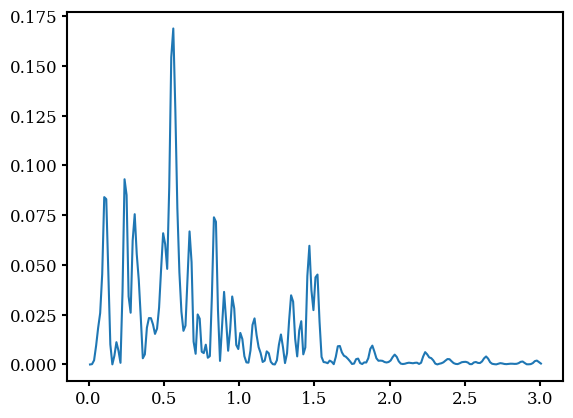

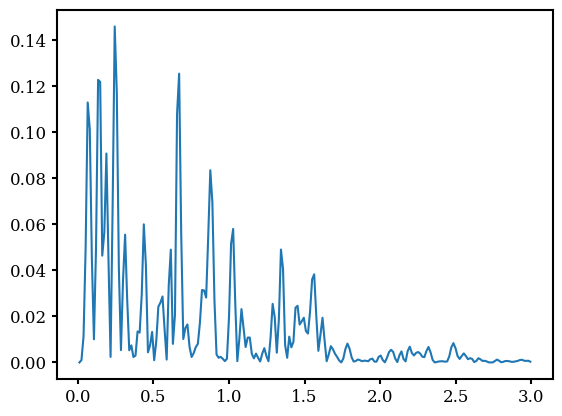

In [47]:
u42_peaks = [0.07546083, 0.14092165, 0.19329032, 0.23256681, 0.36348847, 0.41585713, 
             0.50750228, 0.66460827, 1.45013819]
u42_fap_10 = 0.011953723175525743

u43_peaks = [0.10440271, 0.23926372, 0.30669422, 0.40109693, 0.49549964, 0.56293014, 
             0.67081895, 0.72476336, 0.83265216, 0.90008267, 0.95402707, 1.10237418,
             1.345124, 1.41255451, 1.46649891, 1.52044332]
u43_fap_1 = 0.017248511300774816

u44_peaks = [0.06499718, 0.13374366, 0.18874084, 0.24373803, 0.3124845, 0.39498028, 
             0.43622816, 0.49122535, 0.55997183, 0.61496901, 0.66996619, 0.72496337,
             0.82120844, 0.87620562, 1.02744788, 1.08244506, 1.13744224, 1.28868449,
             1.34368168, 1.39867886, 1.45367604, 1.49492393, 1.56367041, 1.61866759]
u44_fap_1 = 0.010634247630143047

plt.plot(u42_frequency_dt, u42_power_dt)
plt.show()

plt.plot(u43_frequency_dt, u43_power_dt)
plt.show()

plt.plot(u44_frequency_dt, u44_power_dt)
plt.show()

In [9]:
# Load data from u42_stack.npz
u42_data = np.load(directory + "u42_stack.npz")
u42_frequency_dt = u42_data["frequency"]
u42_power_dt = u42_data["power"]
u42_false_alarm_dt = u42_data["false_alarm"]
u42_flux_detrended = u42_data["flux"]
u42_peak_frequencies_dt = u42_data["peak_freqs"]

# Load data from u43_stack.npz
u43_data = np.load(directory + "u43_stack.npz")
u43_frequency_dt = u43_data["frequency"]
u43_power_dt = u43_data["power"]
u43_false_alarm_dt = u43_data["false_alarm"]
u43_flux_detrended = u43_data["flux"]
u43_peak_frequencies_dt = u43_data["peak_freqs"]

# Load data from u44_stack.npz
u44_data = np.load(directory + "u44_stack.npz")
u44_frequency_dt = u44_data["frequency"]
u44_power_dt = u44_data["power"]
u44_false_alarm_dt = u44_data["false_alarm"]
u44_flux_detrended = u44_data["flux"]
u44_peak_frequencies_dt = u44_data["peak_freqs"]

# Load data from n42_stack.npz
n42_data = np.load(directory + "n42_stack.npz")
n42_frequency_dt = n42_data["frequency"]
n42_power_dt = n42_data["power"]
n42_false_alarm_dt = n42_data["false_alarm"]
n42_flux_detrended = n42_data["flux"]
n42_peak_frequencies_dt = n42_data["peak_freqs"]

# Load data from n70_stack.npz
n70_data = np.load(directory + "n70_stack.npz")
n70_frequency_dt = n70_data["frequency"]
n70_power_dt = n70_data["power"]
n70_false_alarm_dt = n70_data["false_alarm"]
n70_flux_detrended = n70_data["flux"]
n70_peak_frequencies_dt = n70_data["peak_freqs"]


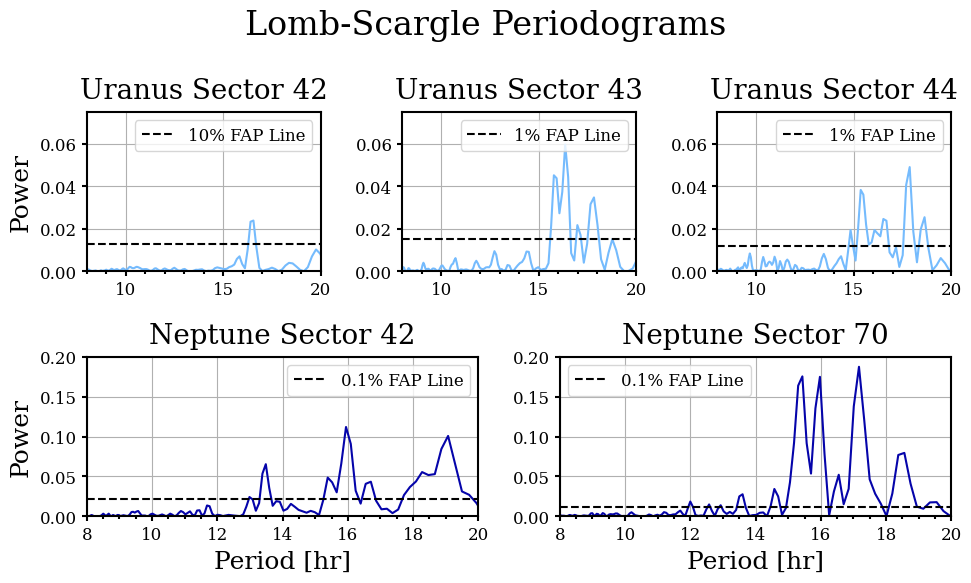

In [10]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def plot_data(axs, name, sector, x, y, fap, fap_percent, color):
    axs.set_title(name + " Sector " + str(sector))
    axs.plot(x, y, color=color), 
    axs.axhline(fap, color='black', linestyle='dashed', label=f'{fap_percent}% FAP Line')
    axs.grid(True)
    axs.set_xlim(8, 20)
    axs.legend(fontsize=12)
    axs.xaxis.set_minor_locator(AutoMinorLocator())

    #axs.set_xticks([0.1, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0])

# Create the figure
fig = plt.figure(figsize=(10, 6))

fig.suptitle("Lomb-Scargle Periodograms", fontsize=24)

# Define a 2-row, 3-column grid
gs = gridspec.GridSpec(2, 6, height_ratios=[1, 1])

# Top row: 3 equal-width panels
ax1 = fig.add_subplot(gs[0, 0:2])
plot_data(ax1, "Uranus", 42, 24/u42_frequency_dt, u42_power_dt, u42_false_alarm_dt, 10, color="xkcd:sky blue")
ax1.set_ylabel("Power")
ax1.set_ylim(0, 0.075)

ax2 = fig.add_subplot(gs[0, 2:4])
plot_data(ax2, "Uranus", 43, 24/u43_frequency_dt, u43_power_dt, u43_false_alarm_dt, 1, color="xkcd:sky blue")
ax2.set_ylim(0, 0.075)

ax3 = fig.add_subplot(gs[0, 4:6])
plot_data(ax3, "Uranus", 44, 24/u44_frequency_dt, u44_power_dt, u44_false_alarm_dt, 1, color="xkcd:sky blue")
ax3.set_ylim(0, 0.075)

# Bottom row: panel 4 on columns 0–1, panel 5 on column 2
ax4 = fig.add_subplot(gs[1, 0:3])
plot_data(ax4, "Neptune", 42, 24/n42_frequency_dt, n42_power_dt, n42_false_alarm_dt, 0.1, color="xkcd:royal blue")
ax4.set_ylabel("Power")
ax4.set_xlabel("Period [hr]")
ax4.set_ylim(0, 0.2)

ax5 = fig.add_subplot(gs[1, 3:6])
plot_data(ax5, "Neptune", 70, 24/n70_frequency_dt, n70_power_dt, n70_false_alarm_dt, 0.1, color="xkcd:royal blue")
ax5.set_xlabel("Period [hr]")
ax5.set_ylim(0, 0.2)

plt.tight_layout()
plt.savefig(directory + "poster_periodogram", dpi=1000)


In [11]:
def hammel_wind_speed(phi):
    return 170 * (0.6 * np.cos(phi) - np.cos(3 * phi))

def sromovsky_wind(phi):
    a = -398
    b = 0.188
    c = -1.2e-5
    return a + b*np.degrees(phi)**2 + c*np.degrees(phi)**4

u42_solutions = [40.37513393]
u42_stdev =  [1.13320667]
u42_wind_speed = hammel_wind_speed(np.radians(u42_solutions))

u43_solutions = [51.63244486, 42.96252028, 34.27850805, 21.29449409]
u43_stdev = [1.45696608, 1.18149908, 1.11851429, 1.35765574]
u43_wind_speed = hammel_wind_speed(np.radians(u43_solutions))

u44_solutions = [71.48033179, 59.13319823, 47.49386962, 40.95031544, 31.86512009, 20.89460628]
u44_stdev = [3.76131785, 2.05279651, 1.25017074, 1.14368911, 1.07887795, 1.35928601]
u44_wind_speed = hammel_wind_speed(np.radians(u44_solutions))

n42_solutions = [ 20.40418511  ,  43.34903644  ,  50.4125404  ,  54.87154083  ,  66.47410736  ,  68.8780702  ]
n42_stdev = [ 1.98285021  ,  0.91502002  ,  0.77616167  ,  0.71173724  ,  0.52898315  ,  0.49635577  ]
n42_wind_speed = sromovsky_wind(np.radians(n42_solutions))

n70_solutions = [10.76217705, 38.20851836, 44.896921, 50.18833308, 54.46338045, 60.36191298, 65.92213368, 69.13734341, 70.67649308, 72.94258766] 
n70_stdev = [3.98535559, 1.04194265, 0.87332508, 0.7950205, 0.71263921, 0.62273291, 0.54012013, 0.48567322, 0.45706343, 0.42475594]
n70_wind_speed = sromovsky_wind(np.radians(n70_solutions))

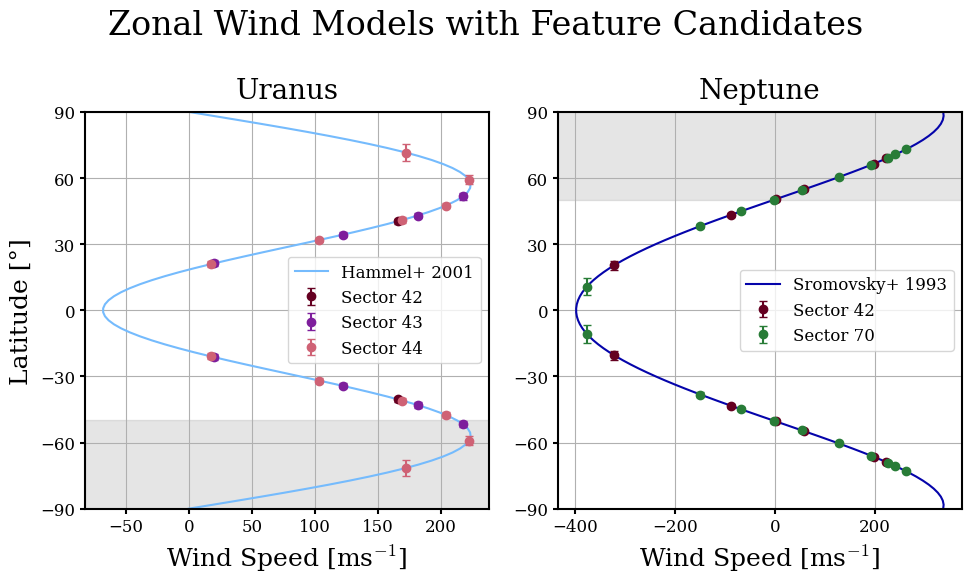

In [12]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def plot_wind(axs):
    axs.grid(True)
    axs.set_yticks(np.arange(-90, 91, 30))
    axs.set_xlabel("Wind Speed [ms$^{-1}$]")
    axs.set_ylim(-90, 90)
    axs.legend(fontsize=12)

phi = np.linspace(-np.pi / 2, np.pi / 2, 100)

# Create the figure
fig = plt.figure(figsize=(10, 6))

fig.suptitle("Zonal Wind Models with Feature Candidates", fontsize=24)

# Define a 2-row, 3-column grid
gs = gridspec.GridSpec(1, 6)

# Top row: 3 equal-width panels
ax1 = fig.add_subplot(gs[0, 0:3])
ax1.set_title("Uranus")
ax1.set_ylabel("Latitude [\u00B0]")
ax1.plot(hammel_wind_speed(phi), np.degrees(phi), color='xkcd:sky blue', label="Hammel+ 2001")
ax1.axhspan(ymin=-150, ymax=-50, color='gray', alpha=0.2)

for i, latitude in enumerate(u42_solutions):
    label = "Sector 42" if i == 0 else None
    ax1.errorbar(u42_wind_speed[i], latitude, yerr=u42_stdev[i], fmt='o', color='xkcd:maroon', capsize=3, label=label)
    ax1.errorbar(u42_wind_speed[i], -latitude, yerr=u42_stdev[i], fmt='o', color='xkcd:maroon', capsize=3)

for i, latitude in enumerate(u43_solutions):
    label = "Sector 43" if i == 0 else None
    ax1.errorbar(u43_wind_speed[i], latitude, yerr=u43_stdev[i], fmt='o', color='xkcd:purple', capsize=3, label=label)
    ax1.errorbar(u43_wind_speed[i], -latitude, yerr=u43_stdev[i], fmt='o', color='xkcd:purple', capsize=3)

for i, latitude in enumerate(u44_solutions):
    label = "Sector 44" if i == 0 else None
    ax1.errorbar(u44_wind_speed[i], latitude, yerr=u44_stdev[i], fmt='o', color='xkcd:rose', capsize=3, label=label)
    ax1.errorbar(u44_wind_speed[i], -latitude, yerr=u44_stdev[i], fmt='o', color='xkcd:rose', capsize=3)

plot_wind(ax1)

ax2 = fig.add_subplot(gs[0, 3:6])
ax2.set_title("Neptune")
ax2.plot(sromovsky_wind(phi), np.degrees(phi), color='xkcd:royal blue', label="Sromovsky+ 1993")
ax2.axhspan(ymin=50, ymax=150, color='gray', alpha=0.2)

for i, latitude in enumerate(n42_solutions):
    label = "Sector 42" if i == 0 else None
    ax2.errorbar(n42_wind_speed[i], latitude, yerr=n42_stdev[i], fmt='o', color='xkcd:maroon', capsize=3, label=label)
    ax2.errorbar(n42_wind_speed[i], -latitude, yerr=n42_stdev[i], fmt='o', color='xkcd:maroon', capsize=3)

for i, latitude in enumerate(n70_solutions):
    label = "Sector 70" if i == 0 else None
    ax2.errorbar(n70_wind_speed[i], latitude, yerr=n70_stdev[i], fmt='o', color='xkcd:darkish green', capsize=3, label=label)
    ax2.errorbar(n70_wind_speed[i], -latitude, yerr=n70_stdev[i], fmt='o', color='xkcd:darkish green', capsize=3)

plot_wind(ax2)

plt.tight_layout()
plt.savefig(directory + "poster_wind", dpi=1000)


In [36]:
print(n42_peak_frequencies_dt)
print(n70_false_alarm_dt)

[0.10602503 0.14717862 0.24320365 0.28435724 0.33922869 0.39410013
 0.54499661 0.59986806 0.72332882 0.77820027 0.95653247 1.1623004
 1.25832543 1.31319688 1.43665764 1.50524695 1.56011839 1.7384506
 1.77960418 1.84819349]
0.011585955350829059
